In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../datasets/raw/saas_features_v2.csv")

# Shape
print("Shape:", df.shape)

# First 5 rows
df.head()

Shape: (111447, 18)


,company_id,user_id,login_time,login_hour,is_weekend,session_duration,failed_login_count,data_transfer_amount,files_accessed,emails_sent,database_queries,usb_usage,vpn_usage,resource_accessed,country,ip_address,risk_label,threat_category
0,T006,U00395,2025-01-16 18:50:18,17,0,132.3,0,139.6,12,7,9,0,0,Customer_DB,Nigeria,192.168.17.129,0,none
1,T003,U00170,2025-01-30 07:09:20,12,0,431.1,0,187.2,10,6,6,0,0,Payroll_DB,Russia,192.168.44.230,0,none
2,T006,U00492,2025-01-13 11:59:24,13,0,343.7,0,154.9,14,4,3,0,0,Cloud_Storage,China,192.168.18.87,0,none
3,T004,U00269,2025-02-17 14:51:43,22,0,185.7,0,135.3,5,0,8,0,0,Finance_Reports,China,192.168.2.46,0,none
4,T005,U00383,2025-02-05 15:13:54,19,0,288.2,2,500.1,29,9,20,1,0,Finance_Reports,China,23.128.194.61,1,insider_threat


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111447 entries, 0 to 111446
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   company_id            111447 non-null  object 
 1   user_id               111447 non-null  object 
 2   login_time            111447 non-null  object 
 3   login_hour            111447 non-null  int64  
 4   is_weekend            111447 non-null  int64  
 5   session_duration      111447 non-null  float64
 6   failed_login_count    111447 non-null  int64  
 7   data_transfer_amount  111447 non-null  float64
 8   files_accessed        111447 non-null  int64  
 9   emails_sent           111447 non-null  int64  
 10  database_queries      111447 non-null  int64  
 11  usb_usage             111447 non-null  int64  
 12  vpn_usage             111447 non-null  int64  
 13  resource_accessed     111447 non-null  object 
 14  country               111447 non-null  object 
 15  

In [3]:
df.dtypes

company_id               object
user_id                  object
login_time               object
login_hour                int64
is_weekend                int64
session_duration        float64
failed_login_count        int64
data_transfer_amount    float64
files_accessed            int64
emails_sent               int64
database_queries          int64
usb_usage                 int64
vpn_usage                 int64
resource_accessed        object
country                  object
ip_address               object
risk_label                int64
threat_category          object
dtype: object

In [4]:
df.isnull().sum()

company_id              0
user_id                 0
login_time              0
login_hour              0
is_weekend              0
session_duration        0
failed_login_count      0
data_transfer_amount    0
files_accessed          0
emails_sent             0
database_queries        0
usb_usage               0
vpn_usage               0
resource_accessed       0
country                 0
ip_address              0
risk_label              0
threat_category         0
dtype: int64

In [5]:
df.describe()

,login_hour,is_weekend,session_duration,failed_login_count,data_transfer_amount,files_accessed,emails_sent,database_queries,usb_usage,vpn_usage,risk_label
count,111447.000000,111447.000000,111447.000000,111447.000000,111447.000000,111447.000000,111447.000000,111447.00000,111447.000000,111447.000000,111447.000000
mean,12.992759,0.284808,279.510056,0.462121,305.314703,12.407422,4.871203,9.33048,0.203254,0.194909,0.257243
std,3.595317,0.451325,94.517906,0.980106,346.523919,10.295544,2.901959,7.92027,0.570795,0.396132,0.437117
min,0.000000,0.000000,10.000000,0.000000,11.300000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,215.000000,0.000000,131.100000,7.000000,3.000000,5.00000,0.000000,0.000000,0.000000
50%,13.000000,0.000000,278.700000,0.000000,210.200000,9.000000,4.000000,7.00000,0.000000,0.000000,0.000000
75%,15.000000,1.000000,342.500000,1.000000,349.400000,13.000000,6.000000,10.00000,0.000000,0.000000,1.000000
max,23.000000,1.000000,801.000000,14.000000,15893.300000,89.000000,30.000000,73.00000,9.000000,1.000000,1.000000


In [6]:
df.describe(include="object")

,company_id,user_id,login_time,resource_accessed,country,ip_address,threat_category
count,111447,111447,111447,111447,111447,111447,111447
unique,8,691,110267,10,10,26585,8
top,T004,U00099,2025-01-26 19:51:42,Payroll_DB,UK,192.168.49.80,none
freq,17495,258,3,13822,17414,18,82778


In [7]:
print(df["risk_label"].value_counts())
print(df["risk_label"].value_counts(normalize=True) * 100)

0    82778
1    28669
Name: risk_label, dtype: int64
0    74.275665
1    25.724335
Name: risk_label, dtype: float64


In [8]:
df["threat_category"].value_counts()

none                    82778
unclassified_anomaly     4703
credential_theft         4458
account_compromise       4257
insider_threat           4213
lateral_movement         3828
data_exfiltration        3611
privilege_abuse          3599
Name: threat_category, dtype: int64

In [9]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate rows: 0


In [10]:
df.isnull().sum()

company_id              0
user_id                 0
login_time              0
login_hour              0
is_weekend              0
session_duration        0
failed_login_count      0
data_transfer_amount    0
files_accessed          0
emails_sent             0
database_queries        0
usb_usage               0
vpn_usage               0
resource_accessed       0
country                 0
ip_address              0
risk_label              0
threat_category         0
dtype: int64

In [11]:
df["login_time"] = pd.to_datetime(df["login_time"])

In [12]:
df.dtypes

company_id                      object
user_id                         object
login_time              datetime64[ns]
login_hour                       int64
is_weekend                       int64
session_duration               float64
failed_login_count               int64
data_transfer_amount           float64
files_accessed                   int64
emails_sent                      int64
database_queries                 int64
usb_usage                        int64
vpn_usage                        int64
resource_accessed               object
country                         object
ip_address                      object
risk_label                       int64
threat_category                 object
dtype: object

In [13]:
numeric_columns = [
    "login_hour",
    "session_duration",
    "failed_login_count",
    "data_transfer_amount",
    "files_accessed",
    "emails_sent",
    "database_queries",
    "usb_usage"
]

df[numeric_columns].describe()

,login_hour,session_duration,failed_login_count,data_transfer_amount,files_accessed,emails_sent,database_queries,usb_usage
count,111447.000000,111447.000000,111447.000000,111447.000000,111447.000000,111447.000000,111447.00000,111447.000000
mean,12.992759,279.510056,0.462121,305.314703,12.407422,4.871203,9.33048,0.203254
std,3.595317,94.517906,0.980106,346.523919,10.295544,2.901959,7.92027,0.570795
min,0.000000,10.000000,0.000000,11.300000,0.000000,0.000000,0.00000,0.000000
25%,11.000000,215.000000,0.000000,131.100000,7.000000,3.000000,5.00000,0.000000
50%,13.000000,278.700000,0.000000,210.200000,9.000000,4.000000,7.00000,0.000000
75%,15.000000,342.500000,1.000000,349.400000,13.000000,6.000000,10.00000,0.000000
max,23.000000,801.000000,14.000000,15893.300000,89.000000,30.000000,73.00000,9.000000


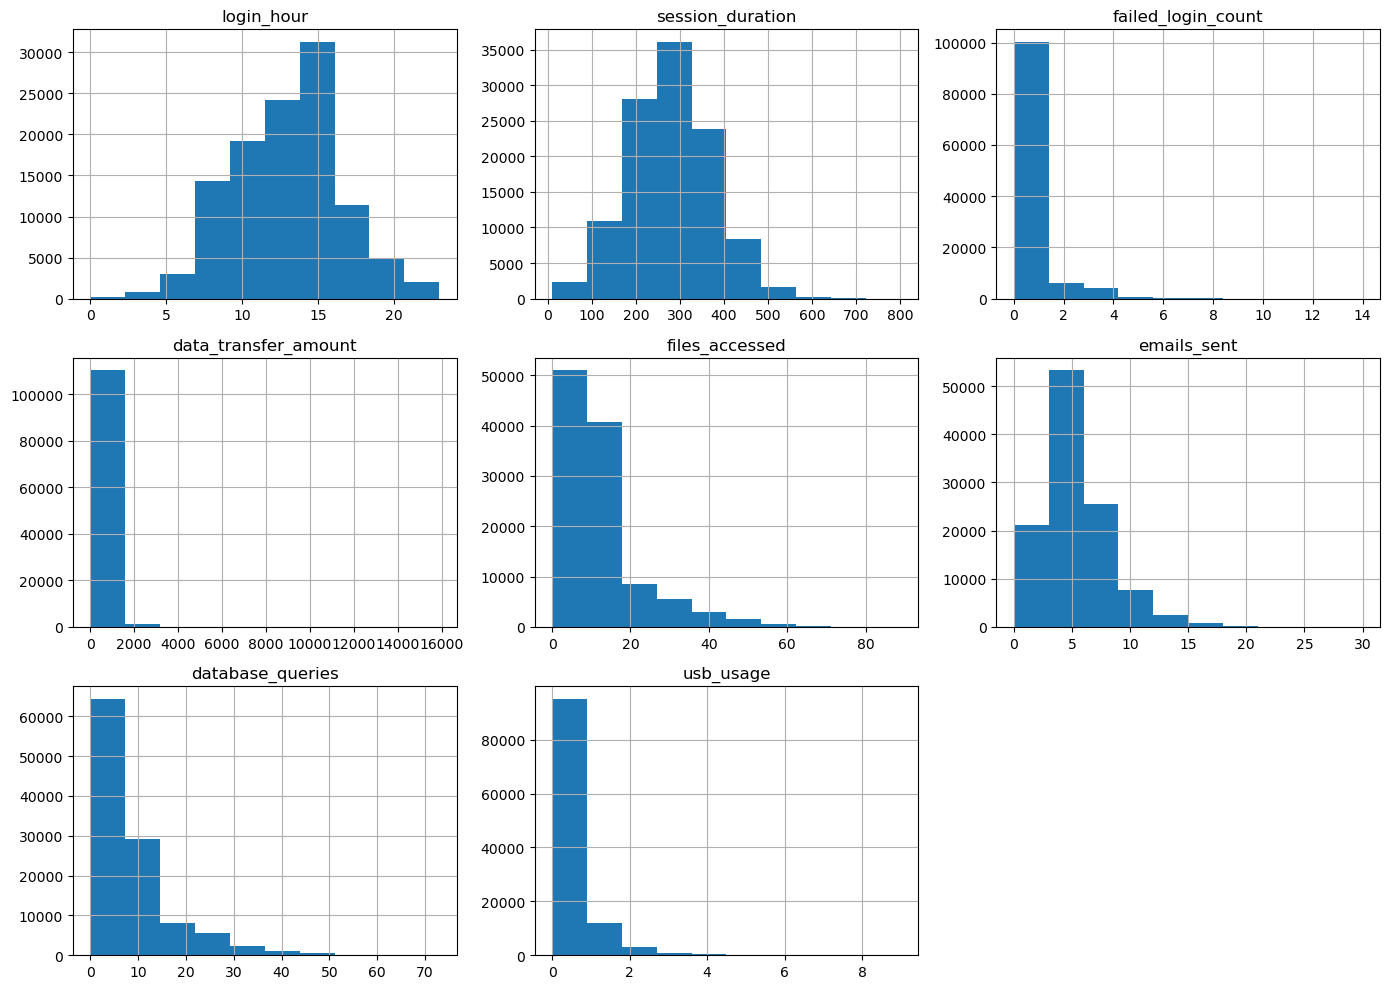

In [14]:
import matplotlib.pyplot as plt
df[numeric_columns].hist(figsize=(14,10))

plt.tight_layout()
plt.show()

## Feature Engineering

In [15]:
# Feature 1: Night Login
df["night_login"] = (
    (df["login_hour"] <= 5) |
    (df["login_hour"] >= 22)
).astype(int)

In [16]:
# Feature 2: Business Hours
df["business_hours"] = (
    (df["login_hour"] >= 9) &
    (df["login_hour"] <= 18)
).astype(int)

In [17]:
# Feature 3: Sensitive Resource Access
sensitive_resources = [
    "Payroll_DB",
    "Finance_Reports",
    "HR_Records",
    "Source_Code"
]

df["sensitive_access"] = (
    df["resource_accessed"].isin(sensitive_resources)
).astype(int)

In [20]:
print(features.shape)
features.head()

(330452, 13)


,user,day,login_count,logoff_count,after_hours_login_count,weekend_login_count,unique_pc_count,connect_count,disconnect_count,after_hours_device,file_access_count,unique_files,after_hours_file
0,AAE0190,2010-01-04,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
1,AAE0190,2010-01-05,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
2,AAE0190,2010-01-06,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
3,AAE0190,2010-01-07,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0
4,AAE0190,2010-01-08,1,1,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# Feature 4: External IP
df["external_ip"] = (
    ~df["ip_address"].str.startswith("192.168.")
).astype(int)

In [19]:
# Feature 5: High Transfer
threshold = df["data_transfer_amount"].quantile(0.95)

df["high_transfer"] = (
    df["data_transfer_amount"] > threshold
).astype(int)

In [20]:
# Feature 5: High Database Queries
threshold = df["database_queries"].quantile(0.95)

df["high_db_queries"] = (
    df["database_queries"] > threshold
).astype(int)

In [22]:
# Feature 5: High File Access
threshold = df["files_accessed"].quantile(0.95)

df["high_file_access"] = (
    df["files_accessed"] > threshold
).astype(int)

In [23]:
# Feature 5: Failed Login Flag
df["failed_login_flag"] = (
    df["failed_login_count"] >= 3
).astype(int)

In [24]:
# Feature 5: Long Session
threshold = df["session_duration"].quantile(0.95)

df["long_session"] = (
    df["session_duration"] > threshold
).astype(int)

In [27]:
features.groupby("user")[
    "file_access_count"
].sum().sort_values(
    ascending=False
).head(10)

user
HSB0196    11627.0
AJF0370    11053.0
LBH0942    10889.0
DLM0051    10673.0
HPH0075     9323.0
MOH0273     9306.0
DBB0384     8543.0
ZKS0899     8537.0
THR0873     8525.0
VIA0063     8524.0
Name: file_access_count, dtype: float64

In [25]:
baseline = df.groupby("user_id").agg({

    "login_hour":"mean",
    "session_duration":"mean",
    "data_transfer_amount":"mean",
    "files_accessed":"mean",
    "database_queries":"mean"

}).rename(columns={

    "login_hour":"avg_login_hour",
    "session_duration":"avg_session",
    "data_transfer_amount":"avg_transfer",
    "files_accessed":"avg_files",
    "database_queries":"avg_queries"

})

baseline.head()

,avg_login_hour,avg_session,avg_transfer,avg_files,avg_queries
user_id,,,,,
U00001,12.583333,282.013542,310.595833,10.458333,8.208333
U00002,12.532258,325.662097,312.299194,16.774194,12.645161
U00003,11.478261,299.546860,191.410145,8.492754,6.555556
U00004,10.903846,226.914423,378.285096,12.471154,9.062500
U00005,11.538462,273.798225,310.714201,10.378698,8.065089


In [26]:
df = df.merge(
    baseline,
    on="user_id",
    how="left"
)

In [27]:
df["login_deviation"] = abs(
    df["login_hour"] -
    df["avg_login_hour"]
)

df["transfer_deviation"] = abs(
    df["data_transfer_amount"] -
    df["avg_transfer"]
)

df["session_deviation"] = abs(
    df["session_duration"] -
    df["avg_session"]
)

df["query_deviation"] = abs(
    df["database_queries"] -
    df["avg_queries"]
)

df["file_deviation"] = abs(
    df["files_accessed"] -
    df["avg_files"]
)

In [29]:
df.to_csv("../datasets/processed/saas_features_processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


In [30]:
features = [
    "login_hour",
    "session_duration",
    "failed_login_count",
    "data_transfer_amount",
    "files_accessed",
    "emails_sent",
    "database_queries",
    "usb_usage",
    "vpn_usage",
    "is_weekend",
    "night_login",
    "business_hours",
    "sensitive_access",
    "external_ip",
    "high_transfer",
    "high_db_queries",
    "high_file_access",
    "failed_login_flag",
    "long_session",
    "login_deviation",
    "transfer_deviation",
    "session_deviation",
    "query_deviation",
    "file_deviation"
]

X = df[features]

In [31]:
import os

os.makedirs("../datasets/processed", exist_ok=True)

df.to_csv("../datasets/processed/saas_features_processed.csv", index=False)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!
